In [1]:
import axelrod as axl
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt


Analysing: 100%|██████████| 25/25 [00:00<00:00, 160.97it/s]
C:\Users\Ognjen\AppData\Local\Temp\ipykernel_13188\476826276.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()
Analysing: 100%|██████████| 25/25 [00:00<00:00, 146.77it/s]
C:\Users\Ognjen\AppData\Local\Temp\ipykernel_13188\476826276.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()
Analysing: 100%|██████████| 25/25 [00:00<00:00, 141.61it/s]
C:\Users\Ognjen\AppData\Local\Temp\ipykernel_13188\476826276.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()
Analysing: 100%|██████████| 25/25 [00:00<00:00, 177.61it/s]
C:\Users\Ognjen\AppData\Local\Temp\ipykernel_13188\476826276.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()
Analysing: 100%|██████████| 25/25 [00:00<00:00, 171.71it/s]
C:\Users\Ognjen\AppData\Local\Temp\ipykernel_13188\476826276.py:35: UserWarning: FigureC

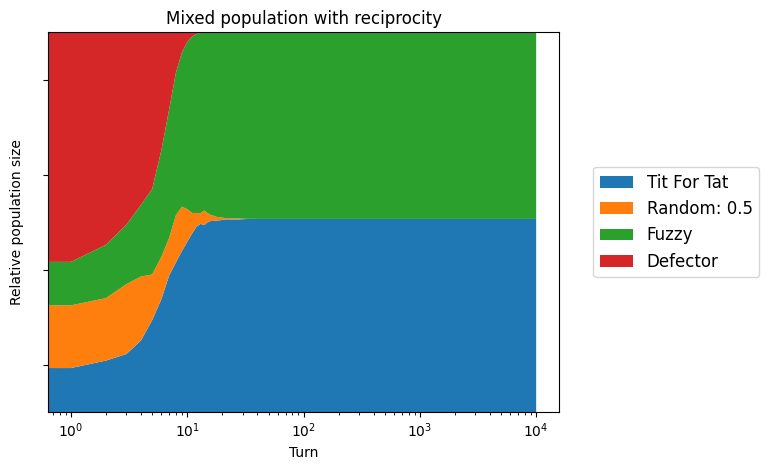

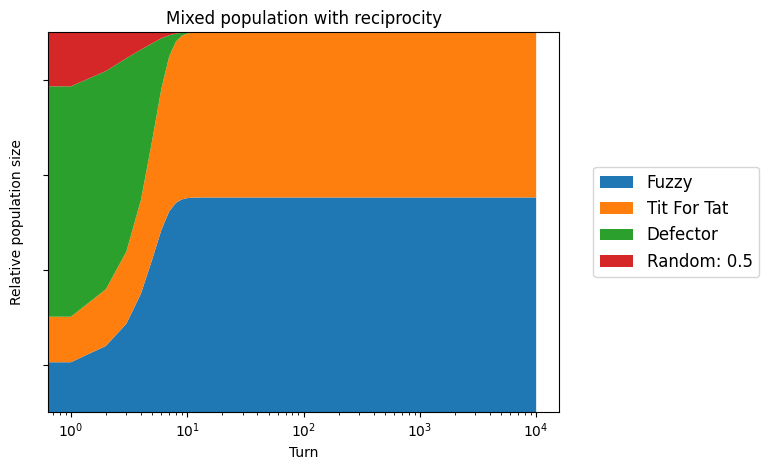

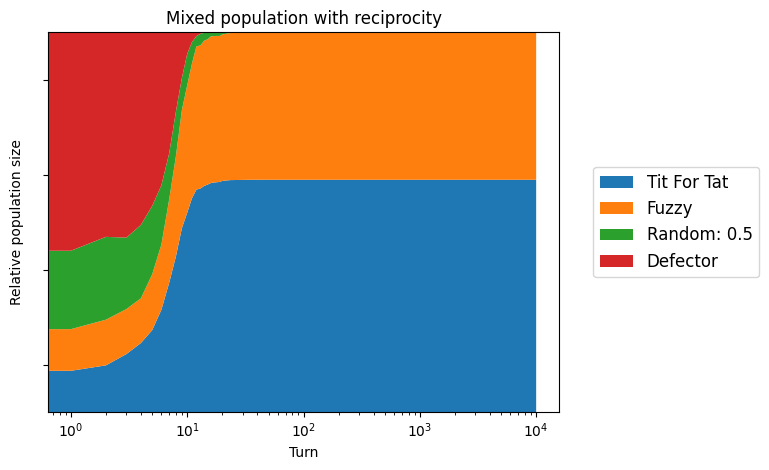

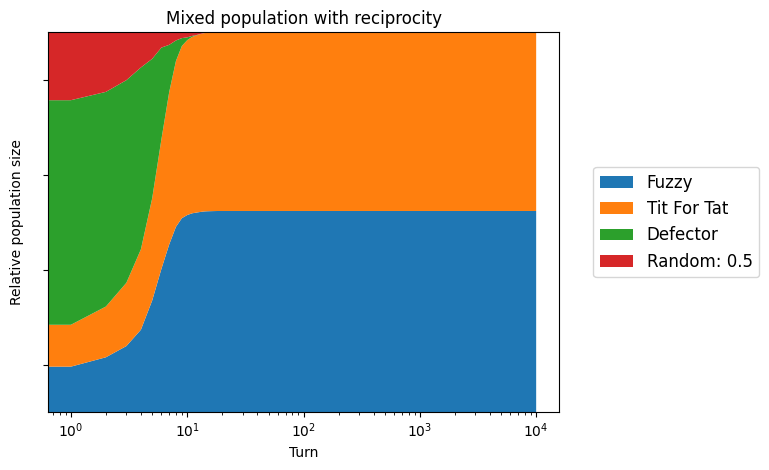

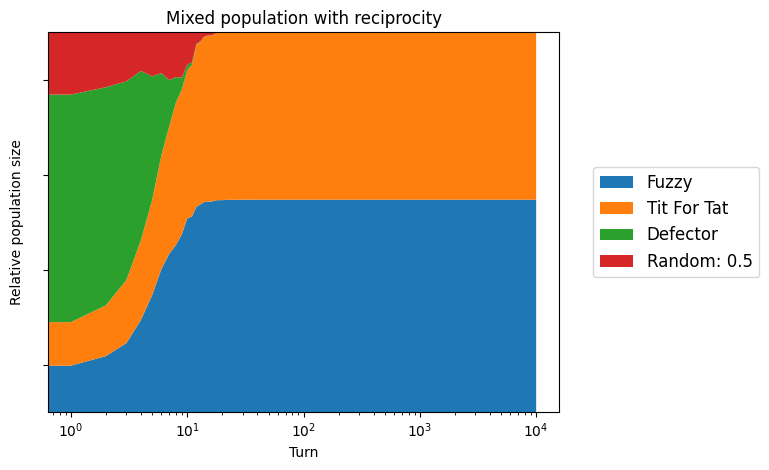

In [2]:
dfs = []


for i in range(0, 5):
    p = [axl.Fuzzy()] + [axl.Defector()] + [axl.Random()] + [axl.TitForTat()]

    t = axl.Tournament(players=p)

    results = t.play()

    eco = axl.Ecosystem(results, population=[0.1, 0.6, 0.2, 0.1])
    eco.reproduce(10000)

    plot = axl.Plot(results)
    p = plot.stackplot(eco, title="Mixed population with reciprocity")

    ax = p.axes[0]
    for txt in ax.texts:
        txt.remove()

    ax.yaxis.set_label_position("left")
    ax.yaxis.labelpad = 10.0

    for txt in ax.texts:
        txt.remove()

    handles = []
    labels = []
    for i, name in enumerate(results.ranked_names):
        color = ax.get_children()[i].get_facecolor()
        handles.append(plt.Rectangle((0,0),1,1, fc=color))
        labels.append(name)

    ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=12)
    p.show()

    df = pd.DataFrame({
        "Strategy": [str(player) for player in t.players],
        "Final Population": eco.population_sizes[-1]
    })
    df = df.sort_values(by="Final Population", ascending=False)

    dfs.append(df)

# 5. Save to Excel
j = 0

writer = pd.ExcelWriter('axelrod_final_population_defective_tft.xlsx', engine='xlsxwriter')

for df in dfs:
    df.to_excel(writer, sheet_name=str(j), index=False)
    j += 1

writer.close()
